In [1]:
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, rdFingerprintGenerator, Fragments
from rdkit.Chem import Draw
import pandas as pd
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np


In [2]:
cat =["[NH4+]",
"CC[NH3+]",
"CCCC[NH3+]",
"CCCCCC[NH3+]",
"C[N+](C)(C)(C)",
"CC[N+](CC)(CC)(CC)",
"CCC[N+](CCC)(CCC)(CCC)",
"CC[N+](C)(C)(C)",
"CCCC[N+](C)(C)(C)",
"CCCCCC[N+](C)(C)(C)",
"C(C)(C)(C)C[N+](C)(C)(C)",
"C1=CC=CC=C1C[N+](C)(C)(C)",
"C1CC[N+](C)(C)C1",
"C1CC[N+](C)(CC)C1",
"C1CC[N+](C)(CCCC)C1",
"C1CC[N+](C)(CCCCCC)C1",
"C1CCC[N+](C)(C)C1",
"C1CCC[N+](CC)(C)C1",
"C1CCC[N+](CCCC)(C)C1",
"C1CCC[N+](CCCCCC)(C)C1",
"C1CC[N+](C2)(CCC2)C1",
"C1CCC[N+](C2)(CCCC2)C1",
"C1CCC[N+](C2)(CCC(CCC)C2)C1",
"C1=CC=C[N+](C)=C1",
"C1=CC=C[N+](CC)=C1",
"C1=CC=C[N+](CCCC)=C1",
"C1=CC=C[N+](CCCCCC)=C1",
"CN1C=C[N+](CC)=C1(C)",
"CN1C=C[N+](CCCC)=C1(C)",
"CN1C=C[N+](CCCCCC)=C1(C)",
"CN1C(C)=C(C)[N+](C)=C1(C)",
"CN1C(C)=C(C)[N+](C)=C1(C1=CC=CC=C1)",
"CN1C2=CC=CC=C2[N+](=C1(C))C",
"CN1C2=CC=CC=C2[N+](=C1C3=CC=CC=C3)C",
"CN1C(C2=CC=CC=C2)=C(C3=CC=CC=C3)[N+](C)=C1(C)",
"CN1C(C2=CC=CC=C2)=C(C3=CC=CC=C3)[N+](C)=C1(C4=CC=CC=C4)",
"[S+](CC)(CC)(CC)",
"[S+](C1=CC=CC=C1)(C2=CC=CC=C2)(C3=CC=CC=C3)",
"[P+](C)(C1=CC=CC=C1)(C2=CC=CC=C2)(C3=CC=CC=C3)",
"[P](N(C)(C))(N(C)(C))(N(C)(C))([NH+](C)(C))"]

      

In [3]:
df = pd.DataFrame()
df["SMILES"]=cat
image_paths= []

for indx, i in enumerate(cat):
    mol = Chem.MolFromSmiles(i)
    mol_image = Draw.MolToImage(mol, size=(150, 150))  # Generate image
    
    df.loc[indx,"MolWt"]= Descriptors.ExactMolWt(mol) #exact molecular weight of the molecule
    df.loc[indx,"HeavyAtomMolWt"] = Descriptors.HeavyAtomMolWt(mol) #average molecular weight of the molecule ignoring hydrogens
    df.loc[indx,"#ValenceElectrons"] = Descriptors.NumValenceElectrons(mol) #number of valence electrons the molecule
    df.loc[indx, "#TertiaryAmines"] = Fragments.fr_NH0(mol) #Number of Tertiary amines
    df.loc[indx, "#SecondaryAmines"] = Fragments.fr_NH1(mol) #Number of Secondary amines
    df.loc[indx, "#PrimaryAmines"] = Fragments.fr_NH2(mol) #Number of Primary amines
    df.loc[indx, "QuaternaryN"]= Fragments.fr_quatN(mol) #Number of quaternary nitrogens
    df.loc[indx, "Molar Refractivity"] = Crippen.MolMR(mol) #Molecular Molar Refractivity 
    df.loc[indx,"PC"]=Crippen.MolLogP(mol) #LogP (Partition Coefficient)
    df.loc[indx,"TPSA"]=rdMolDescriptors.CalcTPSA(mol) #Topological Polar Surface Area (TPSA)"
    df.loc[indx,"NumHDonors"]=Lipinski.NumHDonors(mol) #H-Bond Donors
    df.loc[indx,"NumHAcceptors"]=Lipinski.NumHAcceptors(mol) #H-Bond Acceptors
    df.loc[indx,"PC"]=rdMolDescriptors.CalcNumRotatableBonds(mol) #Rotatable Bonds
    df.loc[indx,"RingCount"]=rdMolDescriptors.CalcNumRings(mol) #Number of Rings
    df.loc[indx,"AromaticCount"]=rdMolDescriptors.CalcNumAromaticRings(mol) #Number of Aromatic Rings
    df.loc[indx,"Fraction"]=rdMolDescriptors.CalcFractionCSP3(mol) #Fraction of sp3 Carbons
    img_path= f"mol_str\mol_{indx}.png"
    #display(indx+1, mol_image)
    mol_image.save(img_path) 
    image_paths.append(img_path)
   
df.to_csv("molecular_descriptors.csv")

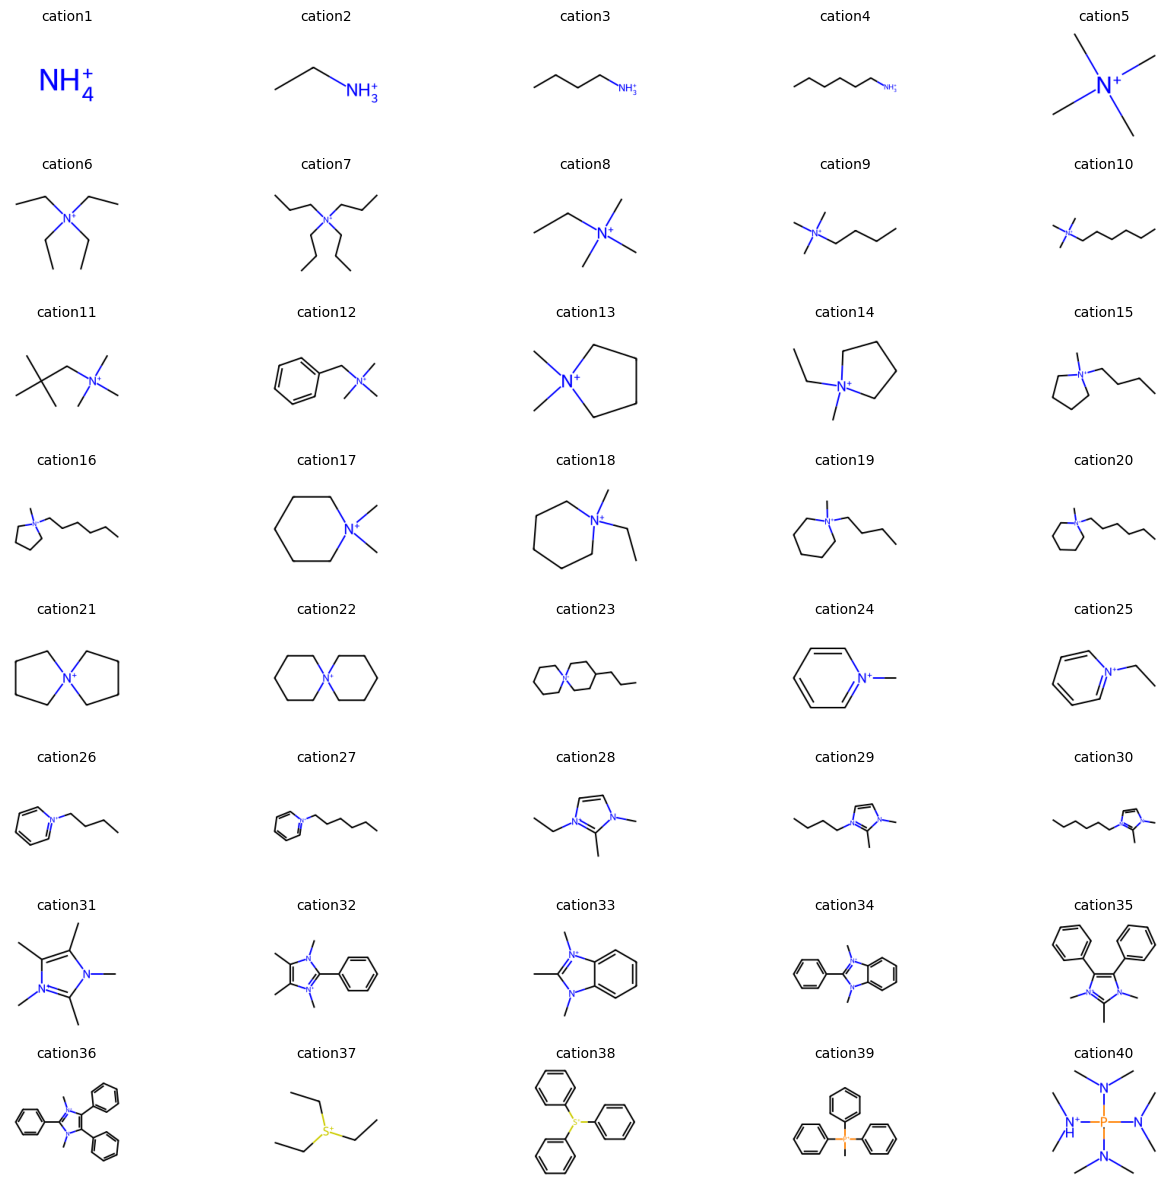

In [4]:
fig, axes = plt.subplots(8, 5, figsize=(14, 12))
axes = axes.flatten()  

for i, image_path in enumerate(image_paths):
    img = mpimg.imread(image_path)
    axes[i].imshow(img)
    axes[i].set_title(f"cation{i+1}", fontsize=10)
    axes[i].axis('off')  # Hide axes ticks and labels

plt.tight_layout()  
plt.savefig("mol_str/cat_grid.png", dpi=300, bbox_inches="tight")
plt.show()


In [5]:
df

,SMILES,MolWt,HeavyAtomMolWt,#ValenceElectrons,#TertiaryAmines,#SecondaryAmines,#PrimaryAmines,QuaternaryN,Molar Refractivity,PC,TPSA,NumHDonors,NumHAcceptors,RingCount,AromaticCount,Fraction
0,[NH4+],18.033826,14.007,8.0,0.0,0.0,0.0,1.0,5.9848,0.0,36.50,1.0,0.0,0.0,0.0,0.000000
1,CC[NH3+],46.065126,38.029,20.0,0.0,0.0,0.0,1.0,13.4291,0.0,27.64,1.0,0.0,0.0,0.0,1.000000
2,CCCC[NH3+],74.096426,62.051,32.0,0.0,0.0,0.0,1.0,22.6631,2.0,27.64,1.0,0.0,0.0,0.0,1.000000
3,CCCCCC[NH3+],102.127726,86.073,44.0,0.0,0.0,0.0,1.0,31.8971,4.0,27.64,1.0,0.0,0.0,0.0,1.000000
4,C[N+](C)(C)(C),74.096426,62.051,32.0,1.0,0.0,0.0,1.0,23.9564,0.0,0.00,0.0,0.0,0.0,0.0,1.000000
5,CC[N+](CC)(CC)(CC),130.159026,110.095,56.0,1.0,0.0,0.0,1.0,42.4244,4.0,0.00,0.0,0.0,0.0,0.0,1.000000
6,CCC[N+](CCC)(CCC)(CCC),186.221626,158.139,80.0,1.0,0.0,0.0,1.0,60.8924,8.0,0.00,0.0,0.0,0.0,0.0,1.000000
7,CC[N+](C)(C)(C),88.112076,74.062,38.0,1.0,0.0,0.0,1.0,28.5734,1.0,0.00,0.0,0.0,0.0,0.0,1.000000
8,CCCC[N+](C)(C)(C),116.143376,98.084,50.0,1.0,0.0,0.0,1.0,37.8074,3.0,0.00,0.0,0.0,0.0,0.0,1.000000
9,CCCCCC[N+](C)(C)(C),144.174676,122.106,62.0,1.0,0.0,0.0,1.0,47.0414,5.0,0.00,0.0,0.0,0.0,0.0,1.000000


In [6]:
#Investigate all descriptors
df_new = pd.DataFrame()
for indx, i in enumerate(cat):
    mol = Chem.MolFromSmiles(i)
    df_new[indx]=Descriptors.CalcMolDescriptors(mol)
df_new.to_csv("mol_desc_all.csv")

In [7]:
df_new.head(10)

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
MaxAbsEStateIndex,0.000000,3.486111,3.675417,3.757491,2.125000,2.274306,2.313472,2.180556,2.231806,2.255899,...,2.203704,2.240741,2.203704,2.240741,2.261574,2.298611,2.273920,2.211420,2.409722,2.335648
MaxEStateIndex,0.000000,3.486111,3.675417,3.757491,2.125000,2.274306,2.313472,2.180556,2.231806,2.255899,...,2.203704,2.240741,2.203704,2.240741,2.261574,2.298611,2.273920,2.211420,2.409722,2.335648
MinAbsEStateIndex,0.000000,1.000000,1.093750,1.111111,1.000000,1.277778,1.333333,1.069444,1.105000,1.114796,...,1.300926,1.255185,1.274259,1.228519,1.238617,1.192876,0.754630,0.014630,1.428148,1.367284
MinEStateIndex,0.000000,1.000000,1.093750,1.111111,1.000000,1.277778,1.333333,1.069444,1.105000,1.114796,...,1.300926,1.255185,1.274259,1.228519,1.238617,1.192876,0.754630,-0.014630,-1.526435,-1.367284
qed,0.393213,0.371491,0.478298,0.508648,0.362984,0.509702,0.509390,0.414091,0.490049,0.410006,...,0.469520,0.625000,0.515090,0.560802,0.625811,0.476136,0.495659,0.596397,0.641560,0.626235
SPS,0.000000,6.000000,8.400000,9.428571,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,10.500000,10.666667,10.916667,10.941176,10.750000,10.800000,10.285714,10.578947,11.250000,13.846154
MolWt,18.039000,46.093000,74.147000,102.201000,74.147000,130.255000,186.363000,88.174000,116.228000,144.282000,...,139.222000,201.293000,161.228000,223.299000,263.364000,325.435000,119.253000,263.385000,277.327000,208.290000
HeavyAtomMolWt,14.007000,38.029000,62.051000,86.073000,62.051000,110.095000,158.139000,74.062000,98.084000,122.106000,...,124.102000,184.157000,148.124000,208.179000,244.212000,304.267000,104.133000,248.265000,259.183000,183.090000
ExactMolWt,18.033826,46.065126,74.096426,102.127726,74.096426,130.159026,186.221626,88.112076,116.143376,144.174676,...,139.122975,201.138625,161.107325,223.122975,263.154275,325.169925,119.088898,263.088898,277.114064,208.181135
NumValenceElectrons,8.000000,20.000000,32.000000,44.000000,32.000000,56.000000,80.000000,38.000000,50.000000,62.000000,...,56.000000,78.000000,62.000000,84.000000,100.000000,122.000000,44.000000,92.000000,98.000000,81.000000
